In [1]:
import random
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.ensemble import GradientBoostingRegressor


In [2]:
DATA_PATH = "/home/haz124/teams/z2/data/steam/cleaned/steam_reviews_full_with_genres.parquet"
pf = pq.ParquetFile(DATA_PATH)

## 1) Load data

We load the cleaned review dataset and keep only the columns needed for this baseline.

**Core columns**
- Text: `review`
- Label: `weighted_vote_score`
- Structured: author stats + playtime + purchase flags

In [3]:
# randomly select 20000 sample reviews.
sample_reviews = 20000

cols = ["review",
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_at_review",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "hidden_in_steam_china",
    "weighted_vote_score"]

chunks = []
n_rows = 0
for rg in range(pf.num_row_groups):
    tbl = pf.read_row_group(rg, columns=cols)
    df_rg = tbl.to_pandas() 

    chunks.append(df_rg)
    n_rows += len(df_rg)

    if (rg+1)%10 == 0:
        print(f"Read row_group{rg+1}/{pf.num_row_groups}, all rows={n_rows:,}",end="\r")
    if n_rows>= sample_reviews:
        break
print("\nFinished reading. Accumulated rows:", n_rows)  

df_all = pd.concat(chunks)
df = df_all.sample(n=sample_reviews, random_state=42).reset_index(drop=True)
df.shape


Finished reading. Accumulated rows: 712710


(20000, 10)

## 2）Features 

We use two types of features:

### Structured
- Author history (number of reviews, games owned)
- Playtime (overall and at review time)
- Purchase flags (steam_purchase, received_for_free, early_access)

These capture reviewer experience and review context.

### Text
- TF-IDF (bag-of-words baseline)
- BERT embeddings (semantic representation)

Text features help capture review content beyond metadata.

## Target label
We predict **review helpfulness** as a regression task.
Target label:  
- `y = log(1 + weighted_vote_score)`  

### Why log1p? 
`weighted_vote_score` is highly skewed (many near 1, few very small).  
`log1p` compresses extreme values and makes regression more stable.

In [4]:
# create label using log(weighted_vote_score)
df["y"] = np.log1p(df["weighted_vote_score"])
df["y"].describe()

count    20000.000000
mean         0.160438
std          0.207311
min          0.000000
25%          0.000000
50%          0.000000
75%          0.407106
max          0.674764
Name: y, dtype: float64

## 3）Train / Validation Split

We use an 80/20 split with a fixed random seed to ensure reproducibility.

In [5]:
# split train and test set
X = df[["author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_at_review",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "hidden_in_steam_china"]]
y = df["y"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
X_train.dtypes

author_num_games_owned         Int64
author_num_reviews             Int64
author_playtime_forever        Int64
author_playtime_at_review      Int64
steam_purchase                  bool
received_for_free               bool
written_during_early_access     bool
hidden_in_steam_china           bool
dtype: object

In [7]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

## 4）Models and Evaluation Metrics

### We evaluate:

- Ridge (structured baseline)
- Decision Tree (non-linear baseline)
- Gradient Boosting (strong tabular model)
- TF-IDF + Ridge
- BERT + Gradient Boosting

This lets us compare structured-only vs text-enhanced models.

### We report RMSE, MAE, and R².

- RMSE / MAE: prediction error (lower is better)
- R²: variance explained (near 0 means little predictive power)

### 4.1 Ridge (structured-only)
Ridge is a strong linear baseline.
It is stable and fast, and helps us see how much signal exists in structured features.

In [8]:
# baseline model using Ridge
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred = model.predict(X_val)

rmse = root_mean_squared_error(y_val, pred)
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)
print("Ridge")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 :", r2)

Ridge
RMSE: 0.20353810011993914
MAE: 0.19436954897106246
R2 : 0.025522635675420124


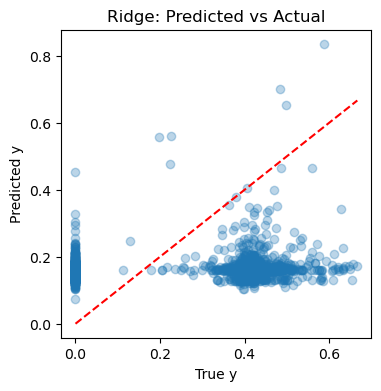

In [9]:
# data visulisation
plt.figure(figsize=(4,4))

plt.scatter(y_val, pred, alpha=0.3, color="tab:blue")

plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         '--', color="red")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Ridge: Predicted vs Actual")
plt.show()

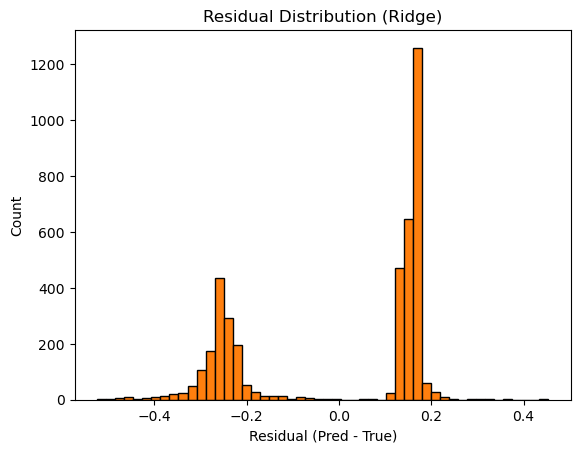

In [10]:
residual = pred - y_val
plt.hist(residual, bins=50, color="tab:orange", edgecolor="black")
plt.xlabel("Residual (Pred - True)")
plt.ylabel("Count")
plt.title("Residual Distribution (Ridge)")
plt.show()

Ridge basically predicts almost the same score for most reviews. It mainly learns the average helpfulness and cannot tell apart very helpful reviews from less helpful ones.
The residual plot also shows that low-helpfulness reviews are usually overestimated, while high-helpfulness reviews are underestimated. This means the model is shrinking everything toward the middle.
Overall, reviewer metadata alone does not explain helpfulness very well, which is why we plan to include review text in later models.

### 4.2 Decision Tree (structured-only)
A tree can model non-linear relationships,
but it may overfit, so we find the best `max_depth`.

In [11]:
# using Decision Tree on structured data
from sklearn.tree import DecisionTreeRegressor

depths = range(2, 21)

train_rmse = []
val_rmse = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)

    pred_train = tree.predict(X_train)
    pred_val = tree.predict(X_val)

    rmse_tr = root_mean_squared_error(y_train, pred_train)
    rmse_va = root_mean_squared_error(y_val, pred_val)

    train_rmse.append(rmse_tr)
    val_rmse.append(rmse_va)

    print(f"Depth {d}: Train RMSE={rmse_tr:.4f}, Val RMSE={rmse_va:.4f}")


Depth 2: Train RMSE=0.2038, Val RMSE=0.2024
Depth 3: Train RMSE=0.2027, Val RMSE=0.2023
Depth 4: Train RMSE=0.2018, Val RMSE=0.2018
Depth 5: Train RMSE=0.2010, Val RMSE=0.2015
Depth 6: Train RMSE=0.1999, Val RMSE=0.2018
Depth 7: Train RMSE=0.1983, Val RMSE=0.2019
Depth 8: Train RMSE=0.1960, Val RMSE=0.2046
Depth 9: Train RMSE=0.1930, Val RMSE=0.2063
Depth 10: Train RMSE=0.1893, Val RMSE=0.2094
Depth 11: Train RMSE=0.1844, Val RMSE=0.2131
Depth 12: Train RMSE=0.1788, Val RMSE=0.2180
Depth 13: Train RMSE=0.1722, Val RMSE=0.2240
Depth 14: Train RMSE=0.1651, Val RMSE=0.2306
Depth 15: Train RMSE=0.1577, Val RMSE=0.2347
Depth 16: Train RMSE=0.1489, Val RMSE=0.2378
Depth 17: Train RMSE=0.1408, Val RMSE=0.2440
Depth 18: Train RMSE=0.1330, Val RMSE=0.2487
Depth 19: Train RMSE=0.1247, Val RMSE=0.2542
Depth 20: Train RMSE=0.1168, Val RMSE=0.2558


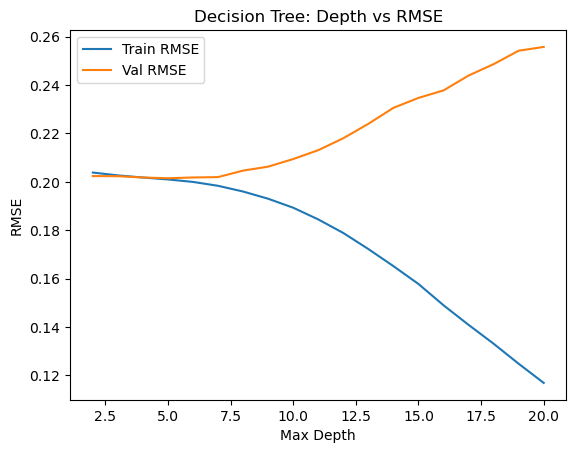

In [12]:
# plot diff
plt.plot(depths, train_rmse, label="Train RMSE")
plt.plot(depths, val_rmse, label="Val RMSE")
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.title("Decision Tree: Depth vs RMSE")
plt.legend()
plt.show()

As the tree gets deeper, it fits the training data better, 
but the validation error gets worse after depth 5. 
This shows clear overfitting, so we choose a shallow tree 
as the best tradeoff.

In [13]:
# let max_depth=5 to store the best decision tree model
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

tree.fit(X_train, y_train)
pred_val_tree = tree.predict(X_val)

rmse_tree = root_mean_squared_error(y_val, pred_val_tree)
mae_tree = mean_absolute_error(y_val, pred_val_tree)
r2_tree = r2_score(y_val, pred_val_tree)
print("Decision Tree(max_depth=5)")
print("RMSE:", rmse_tree)
print("MAE:", mae_tree)
print("R2 :", r2_tree)


Decision Tree(max_depth=5)
RMSE: 0.20146571980793718
MAE: 0.18819784354186442
R2 : 0.045265442674267575


### 4.3 Gradient Boosting (structured-only)
Boosting often performs well on tabular data and captures non-linear interactions,
so we use it as a strong structured baseline.

In [33]:
# Using Gradient Boosting on structured data
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)
pred_val_gbr = gbr.predict(X_val)

rmse_gbr = root_mean_squared_error(y_val, pred_val_gbr)
mae_gbr = mean_absolute_error(y_val, pred_val_gbr)
r2_gbr = r2_score(y_val, pred_val_gbr)
print("Gradient Boosting")
print("RMSE:", rmse_gbr)
print("MAE:", mae_gbr)
print("R2 :", r2_gbr)

Gradient Boosting
RMSE: 0.2002174134320991
MAE: 0.18619356591283073
R2 : 0.057060094020074836


In [34]:
# compare results
print("Quick comparison (lower RMSE/MAE is better, higher R2 is better)")
print(f"Ridge                 RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
print(f"Decision Tree         RMSE={rmse_tree:.4f}  MAE={mae_tree:.4f}  R2={r2_tree:.4f}")
print(f"Gradient Boosting     RMSE={rmse_gbr:.4f}  MAE={mae_gbr:.4f}  R2={r2_gbr:.4f}")

Quick comparison (lower RMSE/MAE is better, higher R2 is better)
Ridge                 RMSE=0.2035  MAE=0.1944  R2=0.0255
Decision Tree         RMSE=0.2015  MAE=0.1882  R2=0.0453
Gradient Boosting     RMSE=0.2002  MAE=0.1862  R2=0.0571


In [35]:
# store and plot the results
results = pd.DataFrame({
    "Model": ["Ridge", "Decision Tree", "Gradient Boosting"],
    "RMSE":  [rmse, rmse_tree, rmse_gbr],
    "MAE":   [mae,  mae_tree,  mae_gbr],
    "R2":    [r2,   r2_tree,   r2_gbr]
})

results

,Model,RMSE,MAE,R2
0,Ridge,0.203538,0.194370,0.025523
1,Decision Tree,0.201466,0.188198,0.045265
2,Gradient Boosting,0.200217,0.186194,0.057060


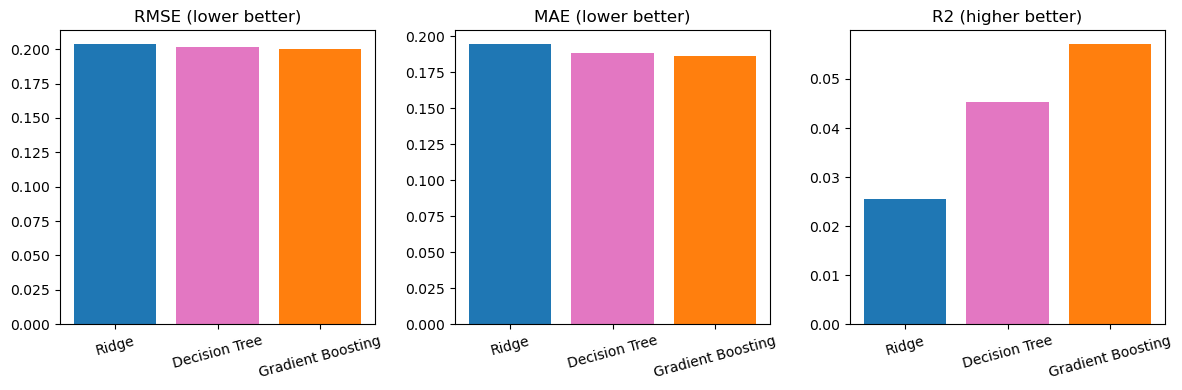

In [17]:
colors = ["tab:blue", "tab:pink", "tab:orange"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# RMSE
axes[0].bar(results["Model"], results["RMSE"], color=colors)
axes[0].set_title("RMSE (lower better)")
axes[0].tick_params(axis='x', rotation=15)

# MAE
axes[1].bar(results["Model"], results["MAE"], color=colors)
axes[1].set_title("MAE (lower better)")
axes[1].tick_params(axis='x', rotation=15)

# R2
axes[2].bar(results["Model"], results["R2"], color=colors)
axes[2].set_title("R2 (higher better)")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


Gradient Boosting achieves the best performance among structured models, but the overall R² is still very low (around 5%). This shows that reviewer metadata alone can't explain most of the perceived helpfulness. Therefore, we expect review text to provide stronger signals.

In [18]:
# Add text feartures:
# 1. using TFIDF+structured+Ridge to train model
# 2. using BERT+structured+GBR to train model

In [19]:
import sys, subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--user",
    "sentence-transformers"
])


0

In [20]:
import sentence_transformers
print(sentence_transformers.__version__)

2026-02-23 00:38:26.971052: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-23 00:38:26.971106: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-23 00:38:26.972600: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-23 00:38:26.979453: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


5.2.2


In [21]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer("paraphrase-MiniLM-L3-v2", device="cpu")

## filtering

We remove invalid text inputs:
- drop `review` that is missing
- drop reviews with length < 20

**Reasoning**
Very short reviews (e.g., "good", "ok") carry little semantic information.
Keeping them increases noise, especially for TF-IDF/BERT features.

In [22]:
# split train and test data
X_struct = df[[
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_at_review",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "hidden_in_steam_china",
]].fillna(0)
y = np.log1p(df["weighted_vote_score"].fillna(0))

X_train_struct, X_val_struct, y_train_struct, y_val_struct = train_test_split(X_struct, y, test_size=0.2, random_state=42)

train_text = df.loc[X_train_struct.index, "review"].fillna("").tolist()
val_text   = df.loc[X_val_struct.index, "review"].fillna("").tolist()


In [23]:
# filter short reviews
MIN_LEN = 20

train_mask = np.array([len(t.strip()) >= MIN_LEN for t in train_text])
val_mask = np.array([len(t.strip()) >= MIN_LEN for t in val_text])

train_text_f = [t for t, m in zip(train_text, train_mask) if m]
val_text_f = [t for t, m in zip(val_text, val_mask) if m]

X_train_struct_f = X_train_struct.astype(float).values[train_mask]
X_val_struct_f = X_val_struct.astype(float).values[val_mask]
y_train_f = y_train.values[train_mask]
y_val_f = y_val.values[val_mask]

print("Train kept:", len(train_text_f), "Val kept:", len(val_text_f))

Train kept: 10064 Val kept: 2505


### 4.4 TF-IDF + Ridge (text + structured)
TF-IDF is a classic bag-of-words representation.
We combine it with structured features to test whether simple text signals help.

In [24]:
# using TFIDF + structured + Ridge
from scipy.sparse import hstack
vectorizer = TfidfVectorizer(max_features=20000, stop_words="english")
X_train_text = vectorizer.fit_transform(train_text_f) 
X_val_text =  vectorizer.transform(val_text_f)

X_train_all_tfidf = hstack([X_train_text, X_train_struct_f])
X_val_all_tfidf = hstack([X_val_text, X_val_struct_f])

ridge_tfidf = Ridge()
ridge_tfidf.fit(X_train_all_tfidf, y_train_f)
pred = ridge_tfidf.predict(X_val_all_tfidf)

rmse_tfidf = root_mean_squared_error(y_val_f, pred)
mae_tfidf = mean_absolute_error(y_val_f, pred)
r2_tfidf = r2_score(y_val_f, pred)
print("TF-IDF + Ridge")
print("RMSE:", rmse_tfidf)
print("MAE:", mae_tfidf)
print("R2 :", r2_tfidf)

TF-IDF + Ridge
RMSE: 0.21332593938049796
MAE: 0.19464046929616496
R2 : -0.006890932821796092


### 4.5 BERT embeddings + Gradient Boosting (text + structured)
BERT embeddings capture semantics beyond word counts.
We optionally apply PCA to reduce dimension and noise, then train a regressor on the combined features.

In [25]:
import os

CACHE_DIR = "./cache_bert"
os.makedirs(CACHE_DIR, exist_ok=True)

MODEL_NAME = "paraphrase-MiniLM-L3-v2"
CACHE_FILE = os.path.join(CACHE_DIR, f"emb_{MODEL_NAME}_train{len(train_text_f)}_val{len(val_text_f)}_minlen{MIN_LEN}.npz")

if os.path.exists(CACHE_FILE):
    print("Loading cached embeddings:", CACHE_FILE)
    data = np.load(CACHE_FILE)
    X_emb_train = data["X_emb_train"]
    X_emb_val   = data["X_emb_val"]
else:
    print("No cache found, encoding...")

    bert_model = SentenceTransformer(MODEL_NAME, device="cpu")

    X_emb_train = bert_model.encode(
        train_text_f, batch_size=32, show_progress_bar=True, convert_to_numpy=True
    )
    X_emb_val = bert_model.encode(
        val_text_f, batch_size=32, show_progress_bar=True, convert_to_numpy=True
    )

    np.savez_compressed(CACHE_FILE, X_emb_train=X_emb_train, X_emb_val=X_emb_val)
    print("Saved cache to:", CACHE_FILE)

print("Emb shapes:", X_emb_train.shape, X_emb_val.shape)


Loading cached embeddings: ./cache_bert/emb_paraphrase-MiniLM-L3-v2_train10064_val2505_minlen20.npz
Emb shapes: (10064, 384) (2505, 384)


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)

X_emb_train_pca = pca.fit_transform(X_emb_train)
X_emb_val_pca   = pca.transform(X_emb_val)

print("Explained variance:", pca.explained_variance_ratio_.sum())

# train the BERT + + structured + gbr model

X_train_all_bert = np.hstack([X_emb_train_pca, X_train_struct_f])
X_val_all_bert = np.hstack([X_emb_val_pca, X_val_struct_f])

bert_gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
bert_gbr.fit(X_train_all_bert, y_train_f)

pred = bert_gbr.predict(X_val_all_bert)

rmse_bert = root_mean_squared_error(y_val_f, pred)
mae_bert = mean_absolute_error(y_val_f, pred)
r2_bert = r2_score(y_val_f, pred)

print("BERT + structured + GBR")
print("RMSE:", rmse_bert)
print("MAE :", mae_bert)
print("R2  :", r2_bert)


Explained variance: 0.7468897
BERT + structured + GBR
RMSE: 0.20605199205879507
MAE : 0.19291224786000186
R2  : 0.060603945901642864


In [27]:
print("Quick comparison (lower RMSE/MAE is better, higher R2 is better)")
print(f"Ridge                          RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
print(f"Decision Tree                  RMSE={rmse_tree:.4f}  MAE={mae_tree:.4f}  R2={r2_tree:.4f}")
print(f"Gradient Boosting              RMSE={rmse_gbr:.4f}  MAE={mae_gbr:.4f}  R2={r2_gbr:.4f}")
print(f"TFIDF + structured + Ridge     RMSE={rmse_tfidf:.4f}  MAE={mae_tfidf:.4f}  R2={r2_tfidf:.4f}")
print(f"BERT + structured + GBR        RMSE={rmse_bert:.4f}  MAE={mae_bert:.4f}  R2={r2_bert:.4f}")


Quick comparison (lower RMSE/MAE is better, higher R2 is better)
Ridge                          RMSE=0.2035  MAE=0.1944  R2=0.0255
Decision Tree                  RMSE=0.2015  MAE=0.1882  R2=0.0453
Gradient Boosting              RMSE=0.2002  MAE=0.1862  R2=0.0571
TFIDF + structured + Ridge     RMSE=0.2133  MAE=0.1946  R2=-0.0069
BERT + structured + GBR        RMSE=0.2061  MAE=0.1929  R2=0.0606


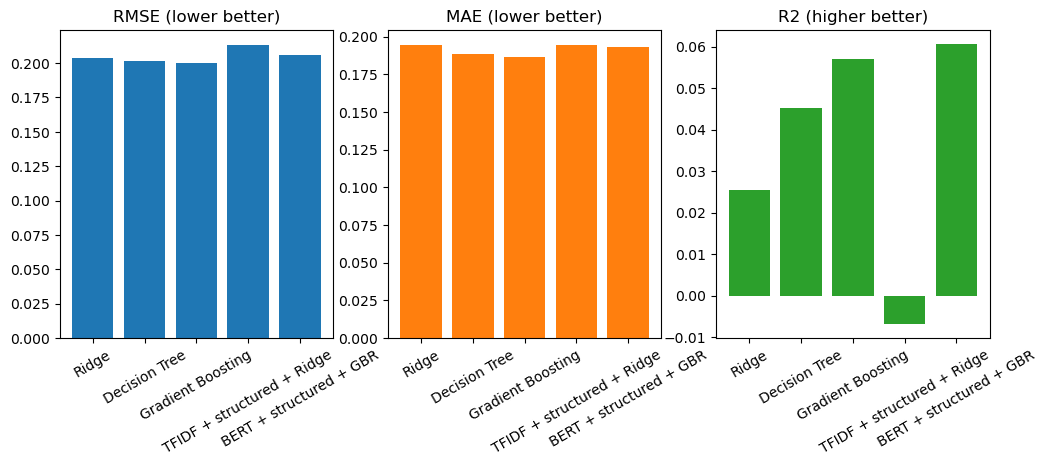

In [28]:
# plot results
colors = ["tab:blue", "tab:pink", "tab:orange"]

models = [
    "Ridge",
    "Decision Tree",
    "Gradient Boosting",
    "TFIDF + structured + Ridge",
    "BERT + structured + GBR"
]

rmse_vals = [rmse, rmse_tree, rmse_gbr, rmse_tfidf, rmse_bert]
mae_vals  = [mae, mae_tree, mae_gbr, mae_tfidf, mae_bert]
r2_vals   = [r2, r2_tree, r2_gbr, r2_tfidf, r2_bert]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# RMSE
axes[0].bar(models, rmse_vals, color="tab:blue")
axes[0].set_title("RMSE (lower better)")
axes[0].tick_params(axis='x', rotation=30)

# MAE
axes[1].bar(models, mae_vals, color="tab:orange")
axes[1].set_title("MAE (lower better)")
axes[1].tick_params(axis='x', rotation=30)

# R2
axes[2].bar(models, r2_vals, color="tab:green")
axes[2].set_title("R2 (higher better)")
axes[2].tick_params(axis='x', rotation=30)

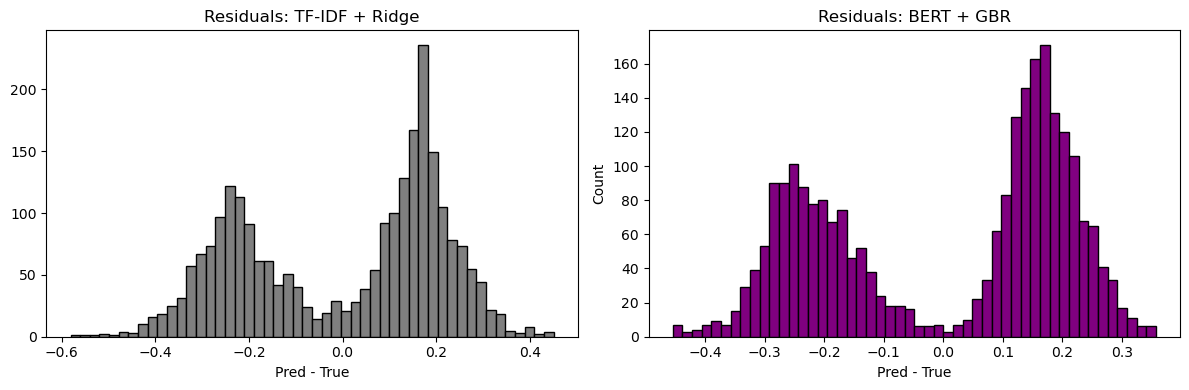

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TF-IDF + Ridge residuals (validation)
residual_tfidf = ridge_tfidf.predict(X_val_all_tfidf) - y_val_f
axes[0].hist(residual_tfidf, bins=50, color="gray", edgecolor="black")
axes[0].set_title("Residuals: TF-IDF + Ridge")
axes[0].set_xlabel("Pred - True")

# BERT + GBR residuals (validation)
residual_gbr = bert_gbr.predict(X_val_all_bert) - y_val_f
axes[1].hist(residual_gbr, bins=50, color="purple", edgecolor="black")
axes[1].set_title("Residuals: BERT + GBR")
axes[1].set_xlabel("Pred - True")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [30]:
# create a sorted(using R2 score) summary table
summary = pd.DataFrame({
    "Model": [
        "Ridge (structured)",
        "Decision Tree",
        "Gradient Boosting",
        "TF-IDF + structured + Ridge",
        "BERT + structured + GBR"
    ],
    "RMSE": [rmse,rmse_tree,rmse_gbr,rmse_tfidf,rmse_bert],
    "MAE": [mae,mae_tree,mae_gbr,mae_tfidf,mae_bert],
    "R2": [r2,r2_tree,r2_gbr,r2_tfidf,r2_bert]
})

summary_sorted = summary.sort_values("R2", ascending=False)
summary_sorted

,Model,RMSE,MAE,R2
4,BERT + structured + GBR,0.206052,0.192912,0.060604
2,Gradient Boosting,0.200217,0.186194,0.057060
1,Decision Tree,0.201466,0.188198,0.045265
0,Ridge (structured),0.203538,0.194370,0.025523
3,TF-IDF + structured + Ridge,0.213326,0.194640,-0.006891


## 5) Error Analysis

many errors come from factors not available in our dataset, such as:
- review visibility and timing
- game popularity
- user exposure on the platform

As a result, even BERT provides only limited improvement, and overall performance remains low.



## 6) Results

Gradient Boosting on structured features performs best.
TF-IDF performs poorly.
BERT provides a small improvement, but overall R² remains low.

This suggests review helpfulness is difficult to predict using available features.